# 머신러닝 - 미션: 항공사 고객 만족도 예측

샘플 129,880명의 항공사 고객 데이터를 활용하여 고객의 만족도를 예측하는 분류 모델을 구축하세요. 

균형잡힌 대규모 데이터셋에서 체계적인 전처리, 효율적인 모델링, 그리고 비즈니스 인사이트 도출을 종합적으로 수행합니다.

### 목표
- 테스트 데이터에서 Accuracy 일정 수준 이상 달성, F1-Score 일정 수준 이상 달성
- 고객 만족도에 영향을 미치는 핵심 요인 파악

### 데이터셋
- 총 샘플 수: 129,880
- 훈련 데이터(`train.csv`): 103,904
- 테스트 데이터(`test.csv`): 25,976
- 타겟 변수: `satisfaction` (satisfied / neutral or dissatisfied)

### 주요 변수 설명
1. 고객 정보:
- Gender: 성별 (Male, Female)
- Customer Type: 고객 유형 (Loyal Customer, disloyal Customer)
- Age: 나이 (7-85세)
- Type of Travel: 여행 목적 (Business travel, Personal Travel)
- Class: 좌석 등급 (Business, Eco Plus, Eco)
2. 비행 정보:
- Flight Distance: 비행 거리 (마일)
- Departure Delay in Minutes: 출발 지연 시간 (분)
- Arrival Delay in Minutes: 도착 지연 시간 (분)
3. 서비스 평가 (1-5점 척도):
- Inflight wifi service: 기내 와이파이
- Departure/Arrival time convenient: 출발/도착 시간 편리성
- Ease of Online booking: 온라인 예약 편리성
- Gate location: 게이트 위치
- Food and drink: 기내 식음료
- Online boarding: 온라인 탑승 수속
- Seat comfort: 좌석 편안함
- Inflight entertainment: 기내 엔터테인먼트
- On-board service: 기내 서비스
- Leg room service: 다리 공간
- Baggage handling: 수하물 처리
- Checkin service: 체크인 서비스
- Inflight service: 기내 서비스
- Cleanliness: 청결도




In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   
2                

C:\Users\USER\AppData\Local\Temp\ipykernel_11244\2358673674.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='satisfaction', palette="coolwarm")


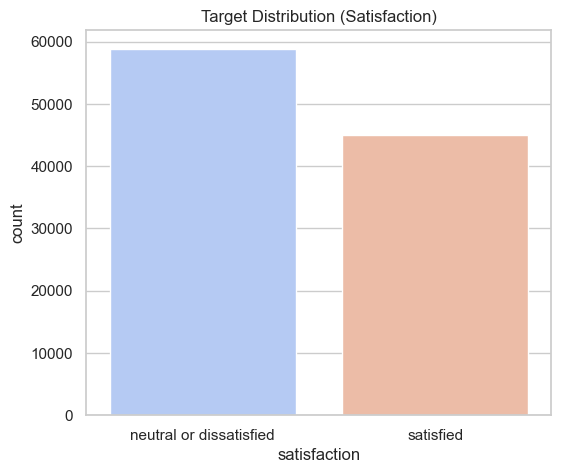


수치형 변수 목록: ['Unnamed: 0', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


,Unnamed: 0,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


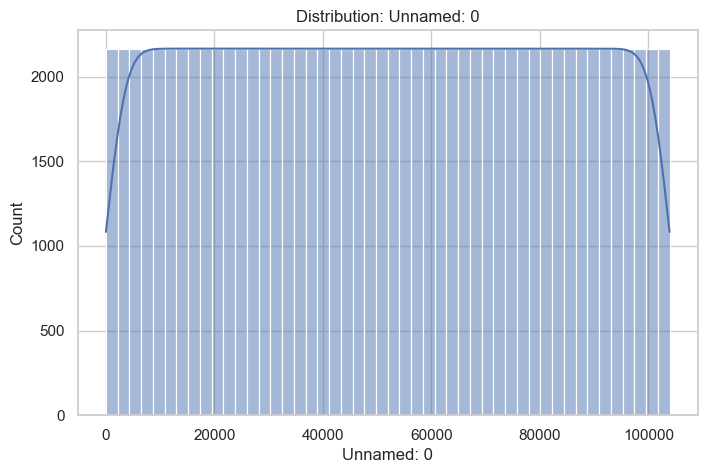

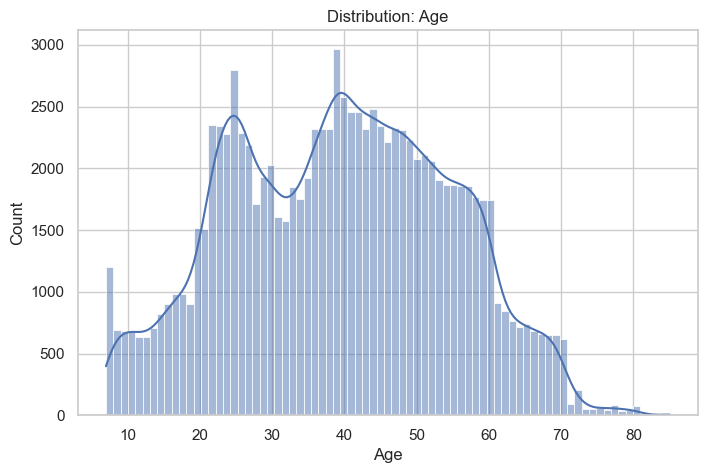

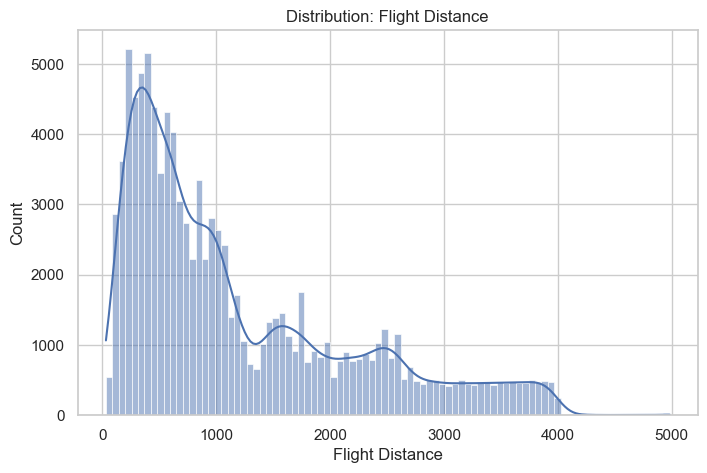

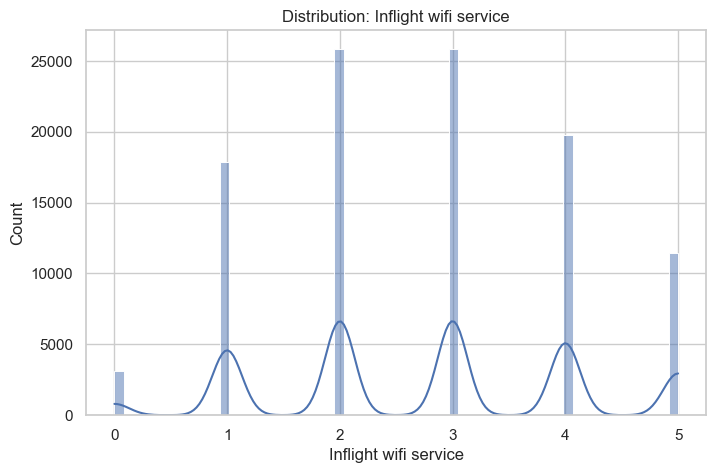

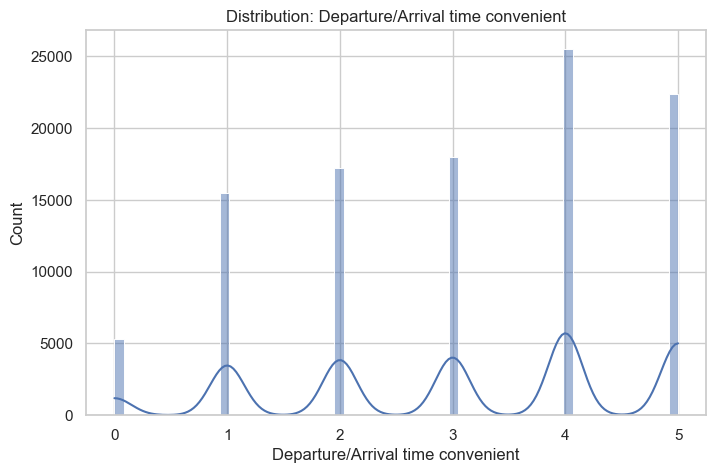

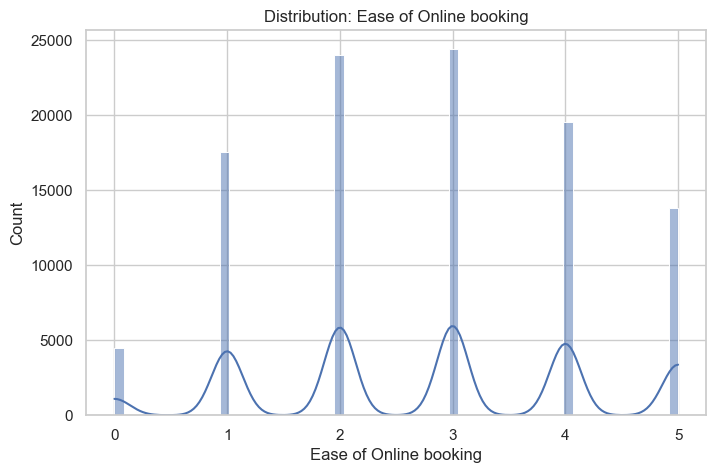

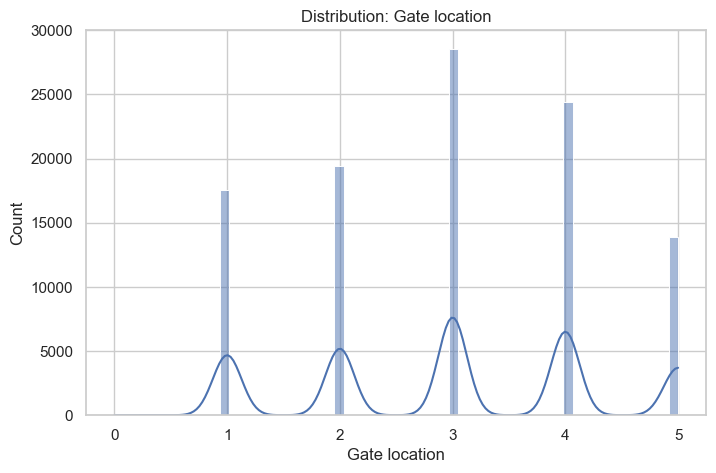

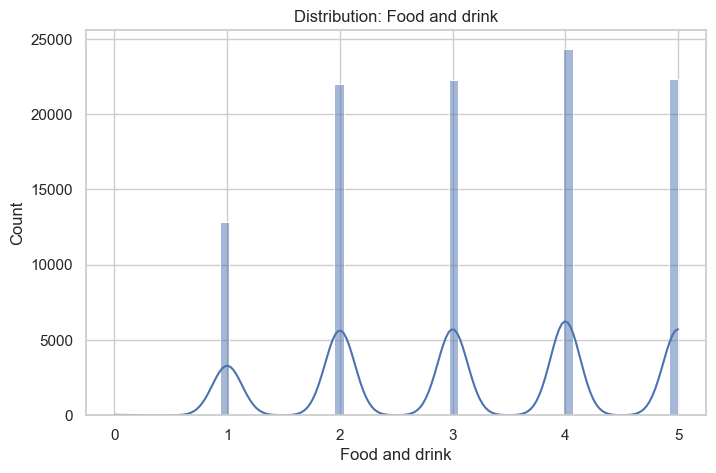

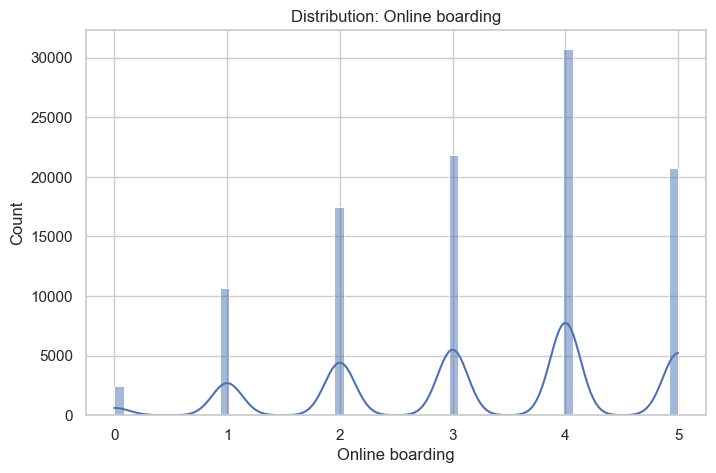

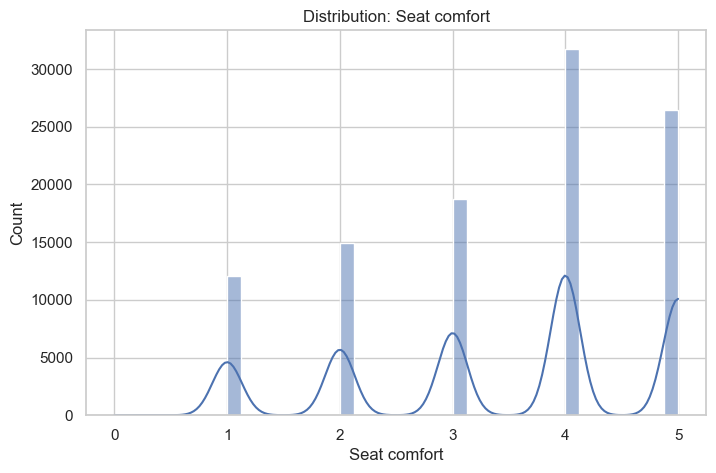

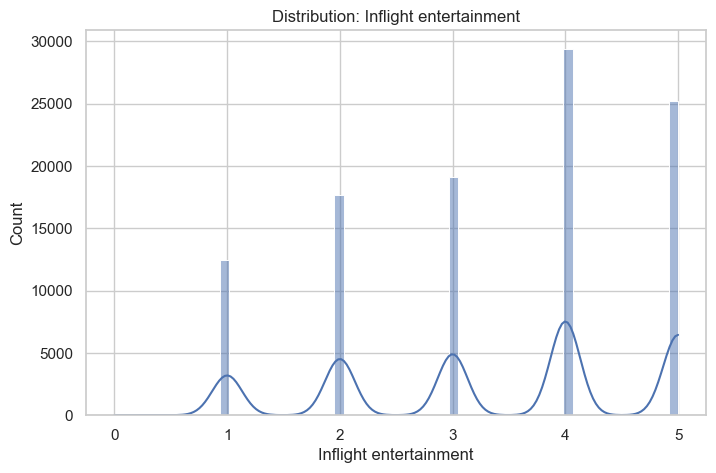

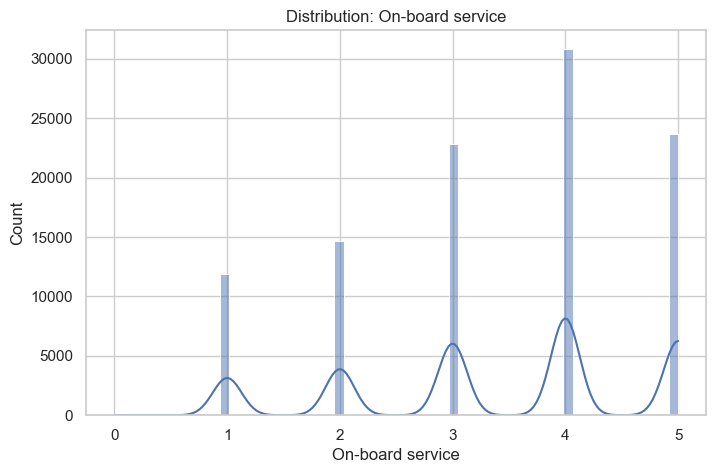

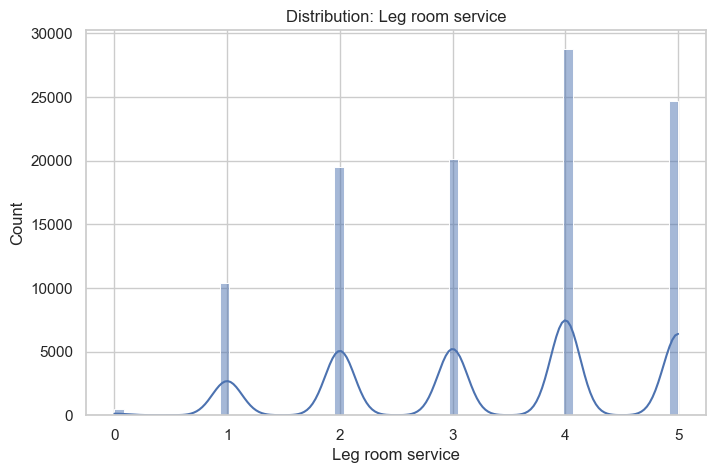

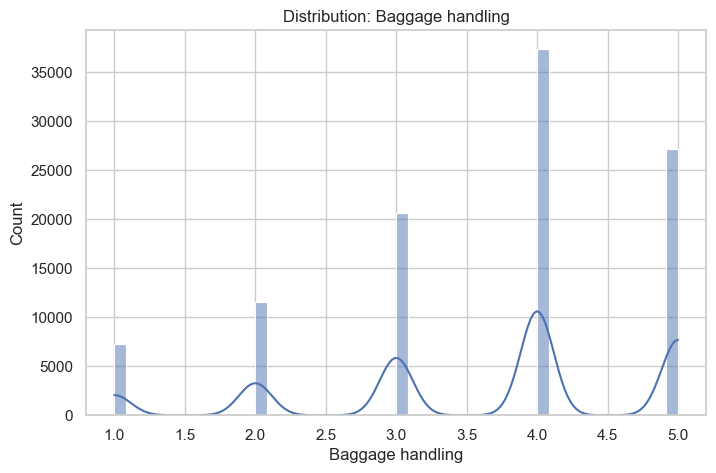

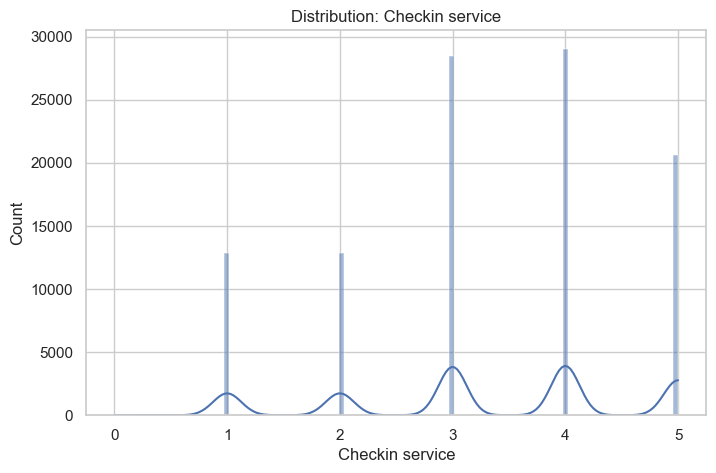

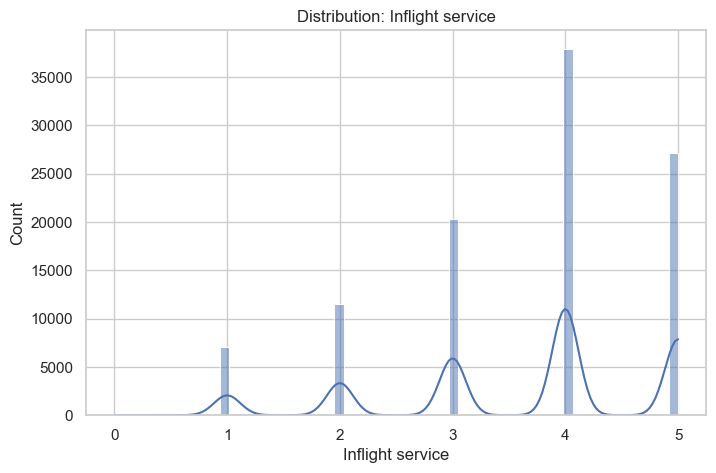

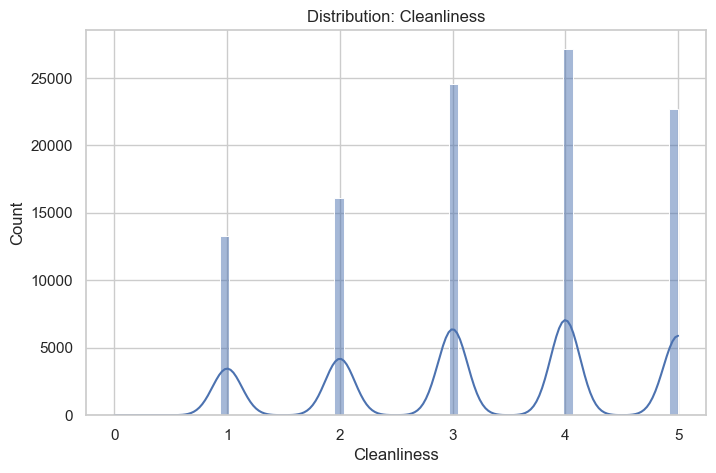

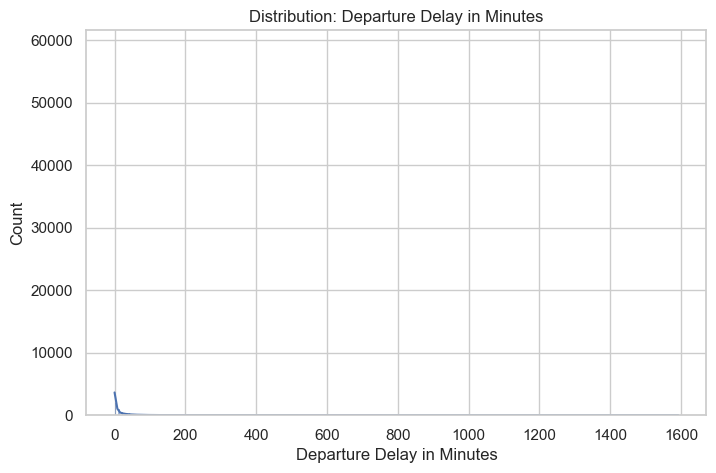

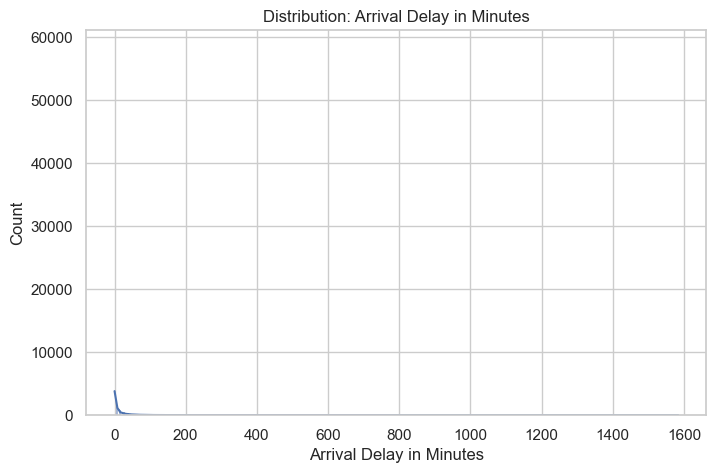


범주형 변수 목록: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


C:\Users\USER\AppData\Local\Temp\ipykernel_11244\2358673674.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette="viridis")


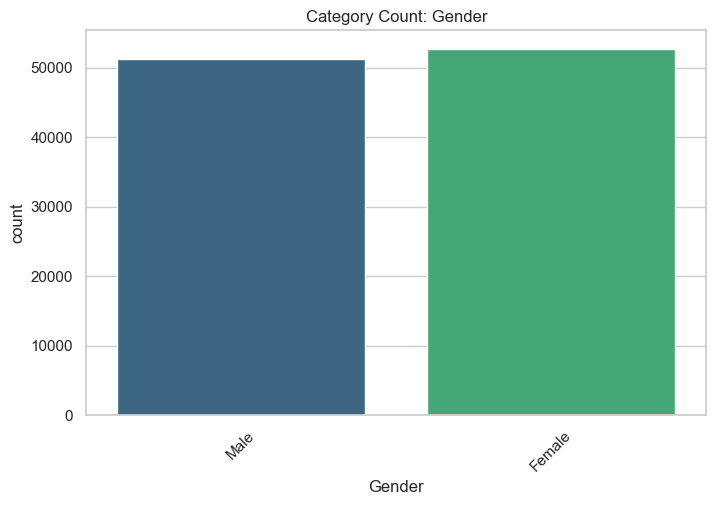

C:\Users\USER\AppData\Local\Temp\ipykernel_11244\2358673674.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette="viridis")


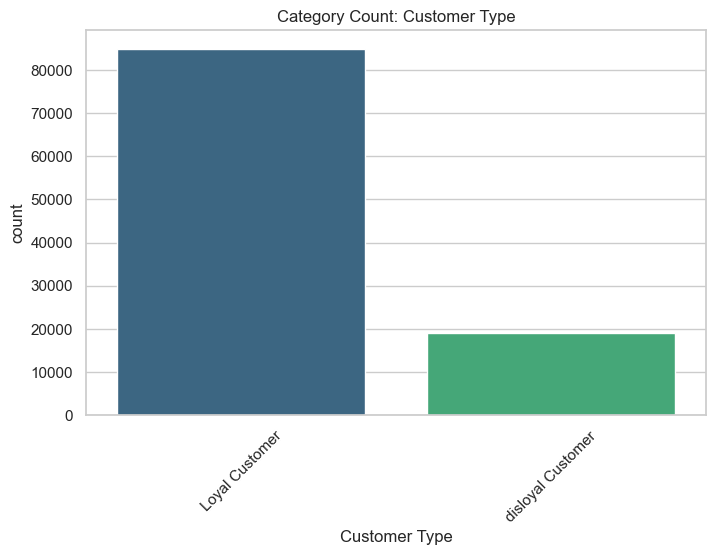

C:\Users\USER\AppData\Local\Temp\ipykernel_11244\2358673674.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette="viridis")


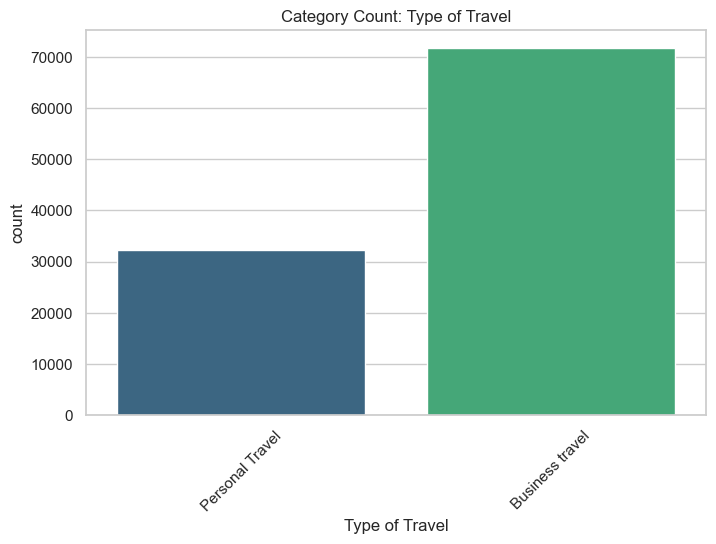

C:\Users\USER\AppData\Local\Temp\ipykernel_11244\2358673674.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x=col, palette="viridis")


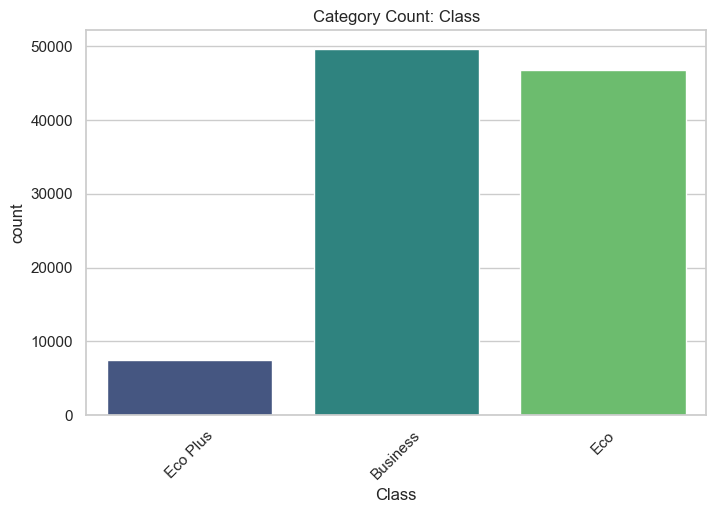

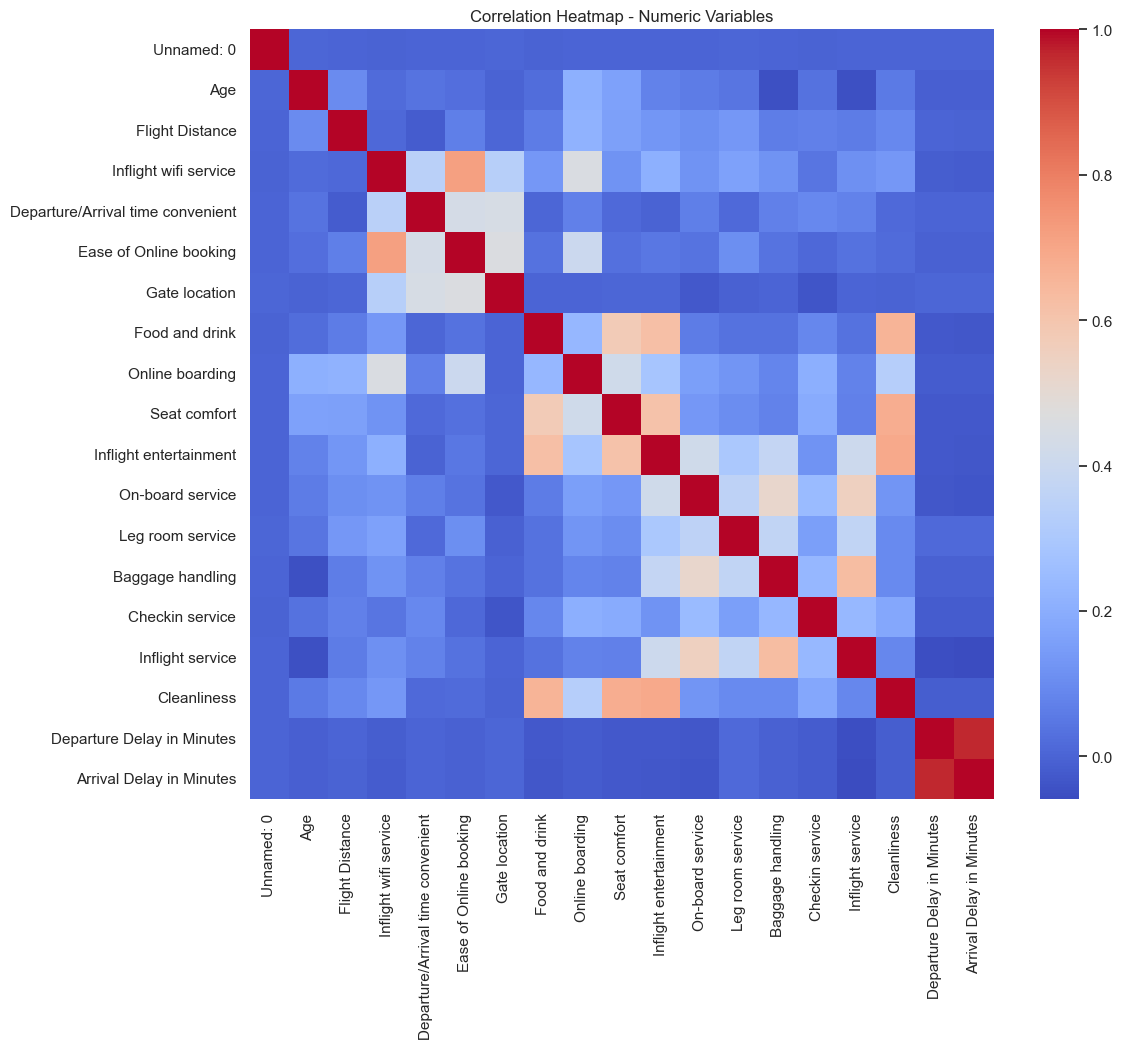

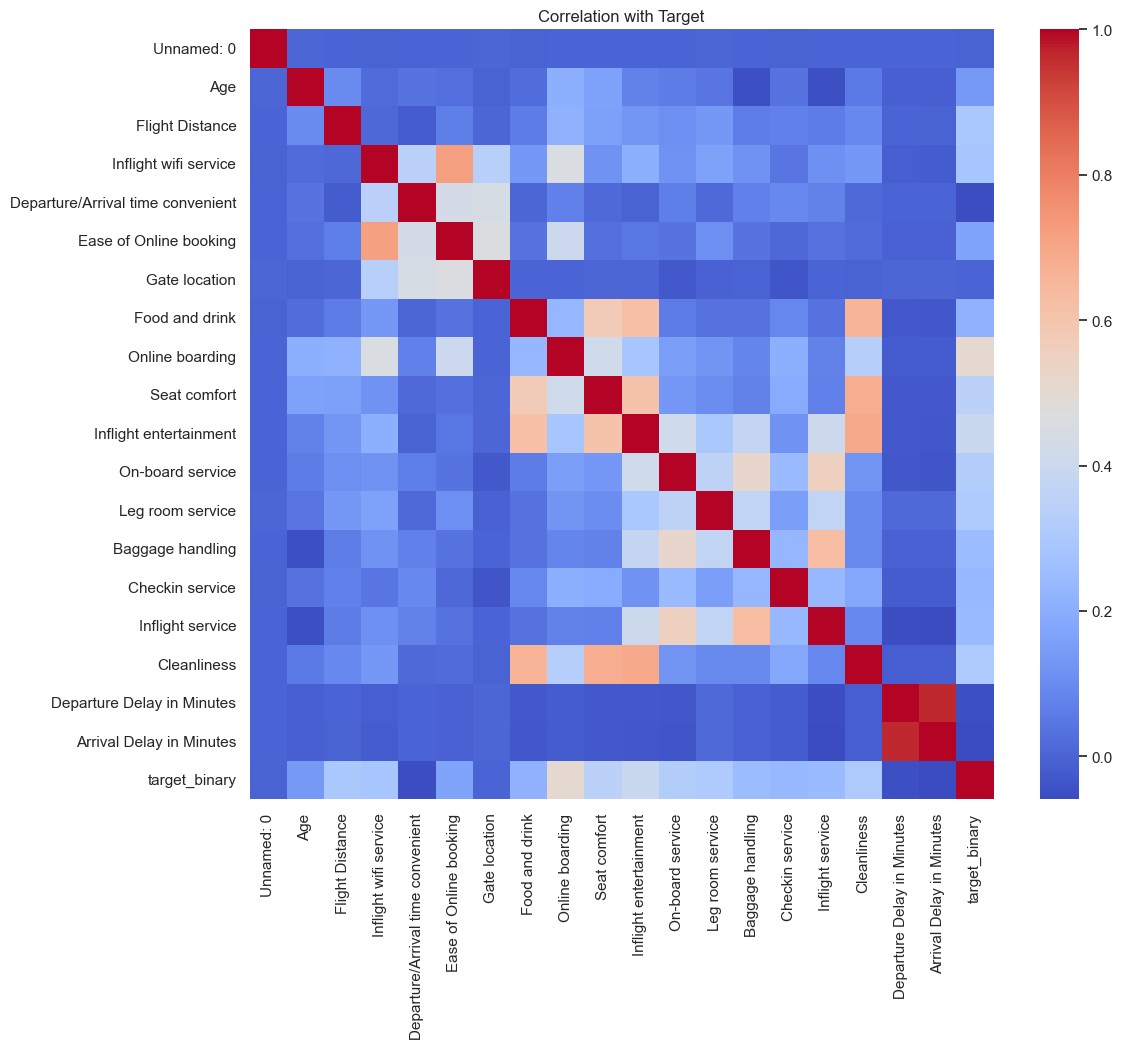


타겟과 상관관계 상위 변수:
target_binary             1.000000
Online boarding           0.503557
Inflight entertainment    0.398059
Seat comfort              0.349459
On-board service          0.322383
Leg room service          0.313131
Cleanliness               0.305198
Flight Distance           0.298780
Inflight wifi service     0.284245
Baggage handling          0.247749
Name: target_binary, dtype: float64


In [8]:
'''
Step 1. 대규모 데이터 탐색 및 이해 (EDA)
- 데이터 로드 및 기본 구조 확인
- 타겟 변수 분석
- 수치형 변수 분석
- 범주형 변수 분석
- 상관관계 분석
'''
train = pd.read_csv('data/train.csv')
# ================================
# Step 1. EDA - 데이터 탐색 및 이해
# ================================

# 시각화 스타일
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ----------------------
# 1. 데이터 로드
# ----------------------

print(train.head())
print("\n데이터 크기:", train.shape)
print("\n데이터 타입 정보:")
print(train.info())

# ----------------------
# 2. 타겟 변수 분석
# ----------------------
print("\n=== Target 변수 분포 ===")
print(train['satisfaction'].value_counts())
print("\n비율:")
print(train['satisfaction'].value_counts(normalize=True))

plt.figure(figsize=(6,5))
sns.countplot(data=train, x='satisfaction', palette="coolwarm")
plt.title("Target Distribution (Satisfaction)")
plt.show()

# ----------------------
# 3. 수치형 변수 탐색
# ----------------------
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('id') if 'id' in numeric_cols else None

print("\n수치형 변수 목록:", numeric_cols)

# 기초 통계량
display(train[numeric_cols].describe())

# 수치형 변수 분포
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.show()

# ----------------------
# 4. 범주형 변수 탐색
# ----------------------
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('satisfaction')  # 타겟 제거

print("\n범주형 변수 목록:", categorical_cols)

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=train, x=col, palette="viridis")
    plt.xticks(rotation=45)
    plt.title(f"Category Count: {col}")
    plt.show()

# ----------------------
# 5. 상관관계 분석
# ----------------------
plt.figure(figsize=(12,10))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Variables")
plt.show()

# 타겟 변수를 숫자로 매핑해서 상관관계 보기
train['target_binary'] = train['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

plt.figure(figsize=(12,10))
corr_target = train[numeric_cols + ['target_binary']].corr()
sns.heatmap(corr_target, annot=False, cmap="coolwarm")
plt.title("Correlation with Target")
plt.show()

# 상관성이 큰 상위 features 확인
print("\n타겟과 상관관계 상위 변수:")
print(corr_target['target_binary'].sort_values(ascending=False).head(10))

# target_binary는 임시로 만든 것 → 제거
train.drop(columns=['target_binary'], inplace=True, errors='ignore')


In [9]:
'''
Step 2. 데이터 전처리
- 결측치 처리
- 파생 변수 생성(필요시)
- 범주형 변수 인코딩 (LabelEncoding, OneHotEncoding)(순서 여부?)
- 수치형 변수 스케일링 (여러가지 방법 시도?)
- 이상치 처리(탐지 후, 유지 vs. 제거)
- 분석에 중요도가 낮은 feauture나 중복되는 feature 제거
'''
# ============================================
# Step 2. 데이터 전처리
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 복사본 생성
df = train.copy()

# ---------------------------
# 1. 결측치 확인
# ---------------------------
print("🔍 결측치 개수:")
print(df.isnull().sum())

# --------------------------------
# 1-1. 결측치 처리 전략
# --------------------------------
# Arrival Delay 결측치 처리
# → Departure Delay 값으로 대체
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Departure Delay in Minutes']
)

print("Arrival Delay 결측치 처리 후 남은 결측치:")
print(df['Arrival Delay in Minutes'].isnull().sum())

print("\n✅ 결측치 처리 완료")


# ---------------------------
# 2. 파생 변수 생성
# ---------------------------

# 1) 지연 관련 변수
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

# 2) 서비스 평균 점수
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]
df['Service Avg Score'] = df[service_cols].mean(axis=1)

print("✅ 파생 변수 생성 완료")


# ---------------------------
# 3. 이상치 처리
# ---------------------------
# 정책: 광범위한 대규모 데이터 → 트리 기반 모델에 영향 거의 없음
# → 제거 대신 cap(클리핑) 적용

# Delay 계열 이상치 upper cap
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Total Delay']:
    df[col] = np.where(df[col] > df[col].quantile(0.99),
                       df[col].quantile(0.99),
                       df[col])

print("✅ 이상치 처리 완료 (99% cap)")


# ---------------------------
# 4. 범주형 변수 인코딩
# ---------------------------

# 타겟 인코딩
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})

# Label Encoding (순서가 없는 명목형)
label_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

print("✅ 범주형 인코딩 완료 (LabelEncoding)")


# ---------------------------
# 5. 스케일링 (수치형 변수)
# ---------------------------
# 트리 모델(LightGBM/XGBoost) → 스케일링 필요 없음
# 그러나 로지스틱/MLP 시도할 수 있으니 StandardScaler 포함

scale_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols.remove('satisfaction')

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("✅ 수치형 변수 스케일링 완료 (StandardScaler)")


# ---------------------------
# 6. Feature 제거 (중요도 낮거나 불필요한 변수)
# ---------------------------

# 'id' 제거
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print("❗ 제거된 Feature: id")
print("⚙️ 현재 데이터 shape:", df.shape)


# ---------------------------
# 최종 X, y 분리
# ---------------------------
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

print("\n🎯 X shape:", X.shape)
print("🎯 y distribution:")
print(y.value_counts(normalize=True))

🔍 결측치 개수:
Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisf

In [10]:
'''
Step 3. 데이터 분할
- 이미 제공된 Train/Test 활용
- Train을 다시 Train(80%) / Validation(20%)으로 분할
- 타겟 비율 유지 (각 세트의 클래스 비율 확인해보기)
'''
# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n📌 Train/Val Split 완료")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)



📌 Train/Val Split 완료
X_train: (83123, 25)
X_val: (20781, 25)


In [11]:
'''
Step 4. 모델 학습 및 기본 평가
- LogisticRegression, DecisionTree, RandomForest, KNN 등의 다양한 모델을 학습 후 비교
- 분류모델의 평가 지표 측정
- Train/Validation 성능 비교
- 상위 2개 모델 선정
'''

# ============================================
# Step 4. 모델 학습 및 기본 평가
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 목록
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = []

# 학습 및 평가 루프
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
display(results_df)

# 상위 2개 모델 선정
top2_models = results_df.head(2)["Model"].tolist()
top2_models


,Model,Accuracy,Precision,Recall,F1-score
2,RandomForest,0.961985,0.967665,0.943809,0.955588
1,DecisionTree,0.946393,0.936015,0.940589,0.938296
3,KNN,0.927337,0.945336,0.883398,0.913318
0,LogisticRegression,0.877051,0.870349,0.841644,0.855756


['RandomForest', 'DecisionTree']

In [12]:
'''
Step 5. 교차 검증
- Stratified K-Fold 교차 검증(k=5 또는 k=10)
- 모든 모델에 대해 수행
- 훈련 점수와 교차 검증 점수 비교
'''
# ============================================
# Step 5. 교차 검증 (Stratified K-Fold)
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=skf,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean F1": np.mean(scores),
        "CV Std": np.std(scores)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV Mean F1", ascending=False)
display(cv_results_df)

cv_results_df


,Model,CV Mean F1,CV Std
2,RandomForest,0.955391,0.001473
1,DecisionTree,0.935257,0.001567
3,KNN,0.910713,0.002398
0,LogisticRegression,0.853085,0.002115


,Model,CV Mean F1,CV Std
2,RandomForest,0.955391,0.001473
1,DecisionTree,0.935257,0.001567
3,KNN,0.910713,0.002398
0,LogisticRegression,0.853085,0.002115


In [13]:
'''
Step 6. 하이퍼 파라미터 튜닝
- GridSearchCV, RandomizedSearchCV(n_iter=30~50)
- cv=5, scoring=f1 또는 accuracy, n_jobs=-1 (병렬처리)
- RandomForest 의 조합 예시
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
- Logistic Regression의 조합 예시
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000, 3000]
- KNN의 조합 예시
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3],  # minkowski에서만 사용됨
'''

# ============================================
# Step 6. 하이퍼파라미터 튜닝
# ============================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

best_models = {}

# ----------------------------
# 1) Logistic Regression
# ----------------------------
if "LogisticRegression" in top2_models:
    lr_params = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    }

    lr_grid = RandomizedSearchCV(
        LogisticRegression(),
        lr_params,
        n_iter=20,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    lr_grid.fit(X_train, y_train)
    best_models["LogisticRegression"] = lr_grid.best_estimator_
    print("Best LR:", lr_grid.best_params_)

# ----------------------------
# 2) RandomForest
# ----------------------------
if "RandomForest" in top2_models:
    rf_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }

    rf_random = RandomizedSearchCV(
        RandomForestClassifier(),
        rf_params,
        n_iter=30,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    rf_random.fit(X_train, y_train)
    best_models["RandomForest"] = rf_random.best_estimator_
    print("Best RF:", rf_random.best_params_)

# ----------------------------
# 3) KNN
# ----------------------------
if "KNN" in top2_models:
    knn_params = {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2, 3]
    }

    knn_grid = RandomizedSearchCV(
        KNeighborsClassifier(),
        knn_params,
        n_iter=30,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    knn_grid.fit(X_train, y_train)
    best_models["KNN"] = knn_grid.best_estimator_
    print("Best KNN:", knn_grid.best_params_)

best_models


Best RF: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


{'RandomForest': RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_split=10,
                        n_estimators=500)}

In [15]:
'''
Step 7. 최종 모델 평가 및 해석
- 주어진 Test 데이터셋으로 분류 모델에 대한 평가 지표 계산
- Confusion Matrix 분석 (오분류 사례 분석)
'''

# =====================================
# Step 7. 최종 모델 평가 및 해석 (test.csv)
# =====================================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) test.csv 불러오기
test = pd.read_csv('data/test.csv')

# ---------------------------
# 2) 결측치 처리
# ---------------------------
test['Arrival Delay in Minutes'] = test['Arrival Delay in Minutes'].fillna(
    test['Departure Delay in Minutes']
)

# ---------------------------
# 3) 파생 변수 생성
# ---------------------------
# Total Delay
test['Total Delay'] = test['Departure Delay in Minutes'] + test['Arrival Delay in Minutes']

# Service Avg Score
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]
test['Service Avg Score'] = test[service_cols].mean(axis=1)

# ---------------------------
# 4) 이상치 처리 (99% cap)
# ---------------------------
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Total Delay']:
    cap = test[col].quantile(0.99)
    test[col] = np.where(test[col] > cap, cap, test[col])

# ---------------------------
# 5) 범주형 LabelEncoding 적용
# ---------------------------
# train에서 사용한 encoder 그대로 사용!
label_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
for col in label_cols:
    test[col] = encoder.transform(test[col])

# ---------------------------
# 6) 수치형 스케일링
# ---------------------------
scale_cols = test.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'satisfaction' in scale_cols:
    scale_cols.remove('satisfaction')
test[scale_cols] = scaler.transform(test[scale_cols])

# ---------------------------
# 7) Feature 제거
# ---------------------------
if 'id' in test.columns:
    test = test.drop(columns=['id'])

# ---------------------------
# 8) X_test, y_test 분리
# ---------------------------
X_test = test.drop(columns=['satisfaction'])
y_test = test['satisfaction']

# ---------------------------
# 9) 예측
# ---------------------------
# Step 6에서 최종 선택된 best_model 사용
y_pred = best_model.predict(X_test)

# ---------------------------
# 10) 평가 지표
# ---------------------------
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("📌 Final Test Accuracy:", round(acc,4))
print("📌 Final Test F1-Score:", round(f1,4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------------------
# 11) Confusion Matrix 시각화
# ---------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


ValueError: y contains previously unseen labels: 'Female'

## 해석 및 종합 보고서